# Bagging — An Illustrated Tour

> **Bagging = Bootstrap AGGregatING.** Train many copies of a high-variance model on bootstrap samples of the data; average their predictions. The variance of the ensemble drops by roughly $1/B$ while the bias stays the same.

---

**What we cover:**
- The bootstrap — sample with replacement
- Why averaging reduces variance — the formula
- A high-variance learner (deep tree) bagged to a smooth predictor
- Bias–variance decomposition: as $B \uparrow$, ensemble variance $\downarrow$, bias unchanged
- Out-of-bag (OOB) error — a free validation set
- Random Forest = bagging + feature subsampling

## The picture — bootstrap many noisy fits, average to cancel variance

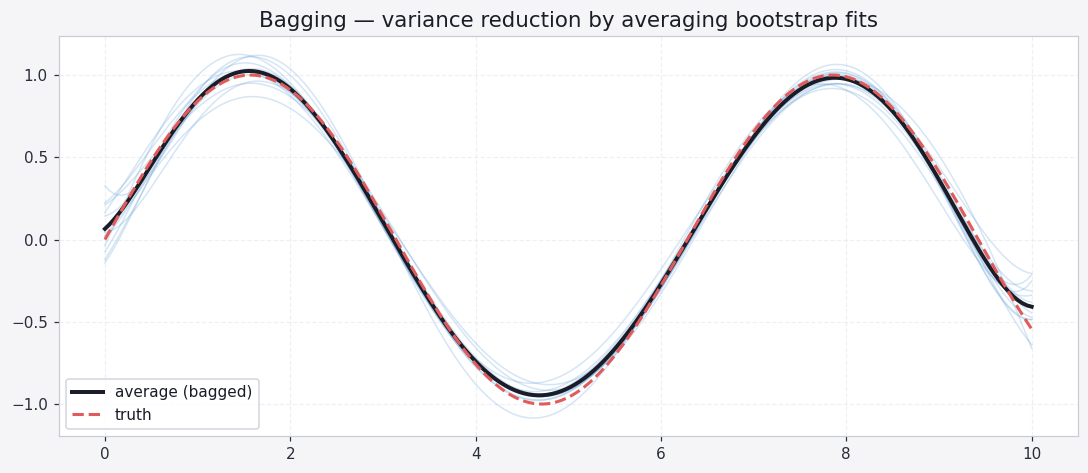

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
x = np.linspace(0, 10, 200); ytrue = np.sin(x)
fig, ax = plt.subplots(figsize=(10, 4.4))
fits = []
for _ in range(12):
    idx = rng.choice(len(x), len(x))
    coef = np.polyfit(x[idx], ytrue[idx] + 0.3*rng.randn(len(x)), 7)
    fits.append(np.polyval(coef, x))
    ax.plot(x, fits[-1], color=P[0], alpha=0.25, lw=1)
ax.plot(x, np.mean(fits, axis=0), color='#1a1d27', lw=2.6, label='average (bagged)')
ax.plot(x, ytrue, color=P[1], lw=2, ls='--', label='truth')
ax.set_title('Bagging — variance reduction by averaging bootstrap fits')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import BaggingRegressor, RandomForestClassifier
from sklearn.datasets import make_moons

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

rng = np.random.default_rng(0)
f = lambda x: np.sin(2*x) + 0.3*x
n = 80
x = np.sort(rng.uniform(-3, 3, n))
y = f(x) + rng.normal(0, 0.4, n)
X = x.reshape(-1, 1)
xs = np.linspace(-3.2, 3.2, 400).reshape(-1, 1)

---
## The Bootstrap

A bootstrap sample of size $n$ is drawn **with replacement** from the training set. About $1 - (1 - 1/n)^n \to 1 - 1/e \approx 63.2\%$ of unique points appear in any sample; the rest are **out-of-bag**.

## Variance of an Average

If $\hat f_b$ are i.i.d. predictors with variance $\sigma^2$ and pairwise correlation $\rho$, the bagged predictor $\bar f = \tfrac{1}{B}\sum_b \hat f_b$ has

$$\operatorname{Var}\bigl(\bar f\bigr) = \rho\sigma^2 + \tfrac{1-\rho}{B}\sigma^2.$$

Increasing $B$ kills the second term, but the first persists — hence Random Forest **decorrelates** trees by random feature selection.

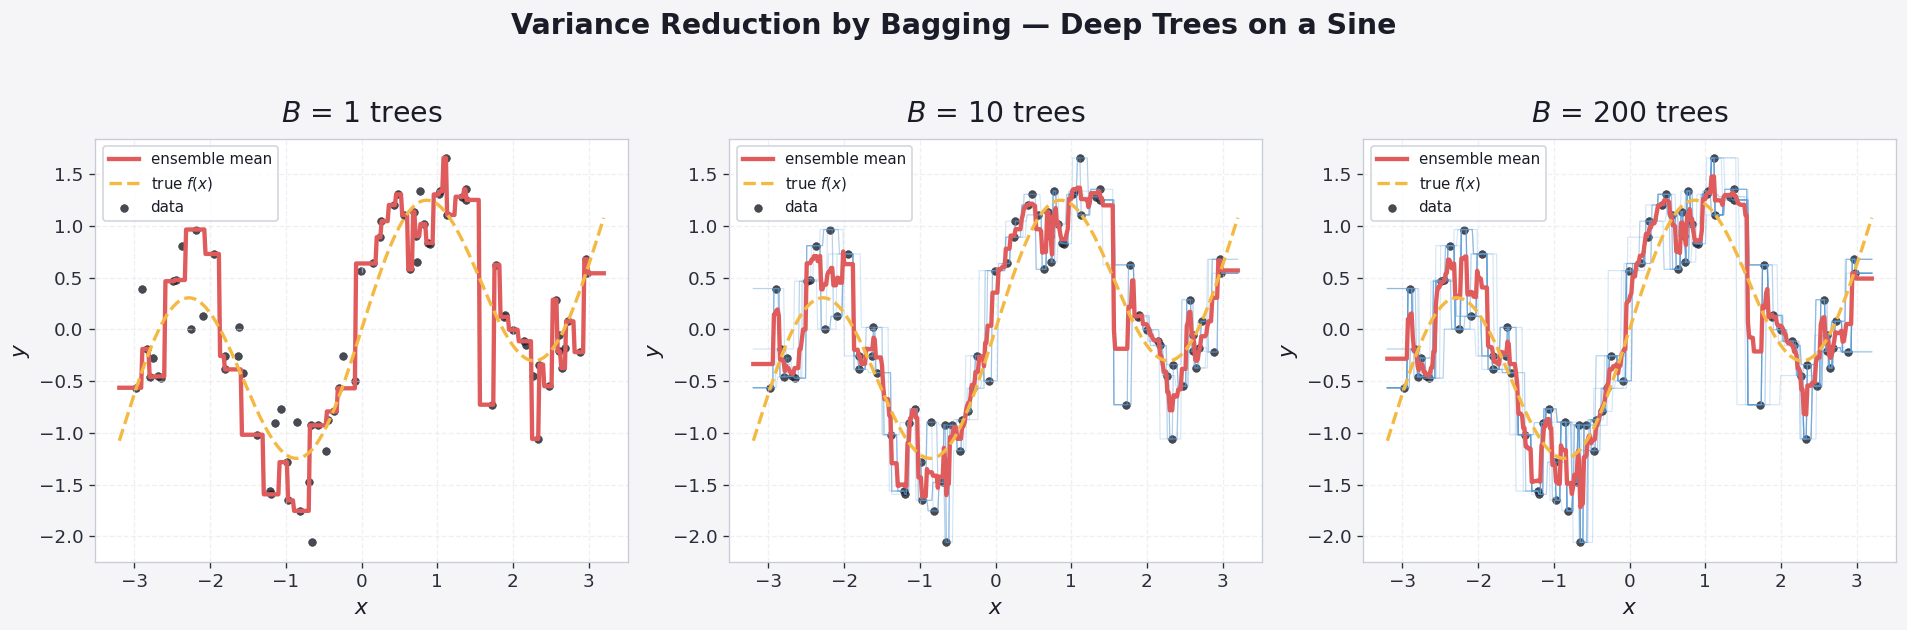

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, n_est in zip(axes, [1, 10, 200]):
    # Show individual bootstrap predictions in light colour
    preds = []
    for b in range(n_est):
        idx = rng.integers(0, n, n)
        m = DecisionTreeRegressor(max_depth=None, random_state=b).fit(X[idx], y[idx])
        preds.append(m.predict(xs))
    preds = np.asarray(preds)
    if n_est > 1:
        for p in preds[:min(20, n_est)]:
            ax.plot(xs, p, color=C0, lw=0.7, alpha=0.25)
    ax.plot(xs, preds.mean(0), color=C1, lw=2.6, label='ensemble mean')
    ax.plot(xs, f(xs.ravel()), color=CB, lw=2, ls='--', label='true $f(x)$')
    ax.scatter(x, y, c='#1a1d27', s=22, edgecolors='#1a1d27', lw=0.3, alpha=0.8, label='data')
    ax.set_title(f'$B$ = {n_est} trees', pad=10)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.grid(True); ax.legend(loc='upper left', fontsize=9)
fig.suptitle('Variance Reduction by Bagging — Deep Trees on a Sine', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Bias–Variance Decomposition

Repeat the experiment over many fresh training sets and plot pointwise bias$^2$ and variance of the predictor at a held-out test point.

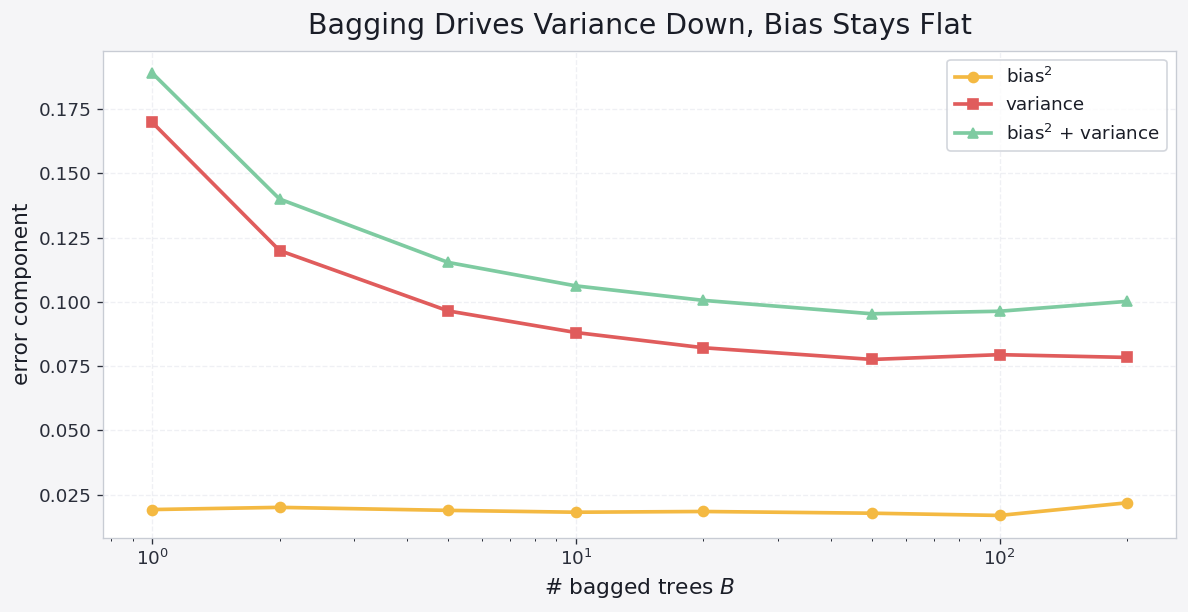

In [4]:
Bs = [1, 2, 5, 10, 20, 50, 100, 200]
n_trials = 60
x_test = xs.ravel()
f_test = f(x_test)

bias_sq = []; var = []
for B in Bs:
    preds_runs = np.zeros((n_trials, len(x_test)))
    for t in range(n_trials):
        x_t = np.sort(rng.uniform(-3, 3, n))
        y_t = f(x_t) + rng.normal(0, 0.4, n)
        bag = BaggingRegressor(DecisionTreeRegressor(), n_estimators=B,
                                random_state=t).fit(x_t.reshape(-1,1), y_t)
        preds_runs[t] = bag.predict(xs)
    mean_pred = preds_runs.mean(0)
    bias_sq.append(np.mean((mean_pred - f_test)**2))
    var.append(np.mean(preds_runs.var(0)))
bias_sq = np.array(bias_sq); var = np.array(var)

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(Bs, bias_sq, color=CB, lw=2.2, marker='o', label='bias$^2$')
ax.plot(Bs, var,     color=C1, lw=2.2, marker='s', label='variance')
ax.plot(Bs, bias_sq + var, color=CM, lw=2.2, marker='^', label='bias$^2$ + variance')
ax.set_xscale('log')
ax.set_xlabel('# bagged trees $B$'); ax.set_ylabel('error component')
ax.set_title('Bagging Drives Variance Down, Bias Stays Flat', pad=10)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Random Forest — Bagging + Feature Subsampling

Random Forests add a twist: at each split, pick a random subset of features. This **decorrelates** the trees ($\rho \downarrow$ in the variance formula), so the ensemble variance drops further.

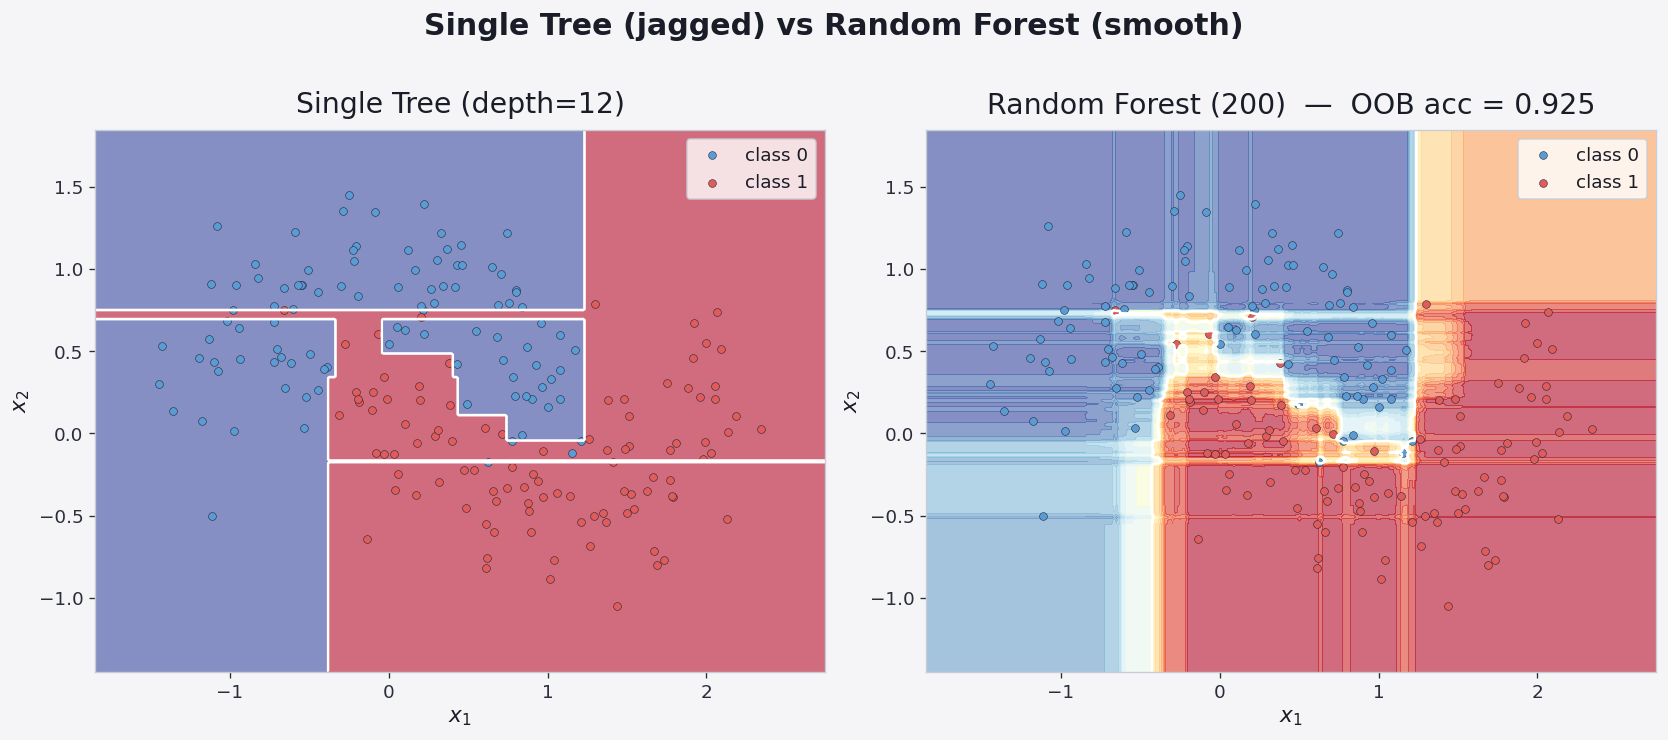

In [5]:
Xc, yc = make_moons(n_samples=200, noise=0.25, random_state=0)
models = {
    'Single Tree (depth=12)': DecisionTreeClassifier(max_depth=12, random_state=0),
    'Random Forest (200)':    RandomForestClassifier(n_estimators=200, random_state=0, oob_score=True),
}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
xx, yy = np.meshgrid(np.linspace(Xc[:,0].min()-0.4, Xc[:,0].max()+0.4, 300),
                     np.linspace(Xc[:,1].min()-0.4, Xc[:,1].max()+0.4, 300))
for ax, (name, m) in zip(axes, models.items()):
    m.fit(Xc, yc)
    Z = m.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='#ffffff', linewidths=1.6)
    ax.scatter(Xc[yc==0,0], Xc[yc==0,1], c=C0, s=22, edgecolors='#1a1d27', lw=0.3, label='class 0')
    ax.scatter(Xc[yc==1,0], Xc[yc==1,1], c=C1, s=22, edgecolors='#1a1d27', lw=0.3, label='class 1')
    title = name + (f'  —  OOB acc = {m.oob_score_:.3f}' if hasattr(m, 'oob_score_') else '')
    ax.set_title(title, pad=10); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(loc='upper right')
fig.suptitle('Single Tree (jagged) vs Random Forest (smooth)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use Bagging — and when not to

| Situation | Bagging | Boosting | Stacking | Single model |
|---|---|---|---|---|
| Base learner is high-variance | ✅ deep tree, KNN | ❌ wants weak | partial | ❌ |
| Base learner is high-bias | ❌ no benefit | ✅ stumps | partial | ❌ |
| Need parallel training | ✅ embarrassingly | ❌ sequential | partial | ✅ |
| Need calibrated uncertainty | ✅ predictive variance | partial | partial | partial |

> Bagging fights **variance**. Boosting fights **bias**. Choose by which one dominates your error.


---
## 🎯 Try this

1. **Pasting vs bagging.** Set `bootstrap=False` and observe — diversity drops; ensemble variance reduction shrinks.
2. **OOB confidence intervals.** Build a 90% interval from the spread of bootstrap predictions. Check empirical coverage on a held-out set.
3. **Bagging a strong learner.** Bag a tuned XGBoost model. The accuracy gain should be tiny — boosting already used most of the variance budget.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Bootstrap | Sample $n$ points **with** replacement | ~63% unique → OOB validation comes free |
| Bagging | Train $B$ models on bootstraps; average | Variance $\propto \rho\sigma^2 + \tfrac{1-\rho}{B}\sigma^2$ |
| Bias | Unchanged by bagging | Use a low-bias base learner (deep trees) |
| OOB error | Test on points not in each bag | Honest estimate without held-out set |
| Random Forest | Bagging + per-split feature subsampling | Decorrelates trees → lower $\rho$ |
| When to use | High-variance learners (deep trees, kNN with small $k$) | Pointless on already-low-variance models (linear regression) |

**Bottom line:** Bagging is the **variance-killing knob** of ensemble learning. Pick a high-variance base learner, average many bootstrap copies, and — for trees — sprinkle in feature subsampling to crush the residual correlation.